# TRANING PROCESS OF TRACKNETV5 - 5 Frames

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'einops', '--quiet'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, torch

YOLO_DATASET_DIR = '/content/drive/MyDrive/In_Out_Pickleball/yolo_dataset_v3'

TN_OUT_DIR = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch'

ORIG_W = 1920
ORIG_H = 1080

IMG_W, IMG_H   = 512, 288
HEATMAP_RADIUS = 40
N_FRAMES       = 5

N_INTERVALS    = N_FRAMES - 1
IN_CH_BACKBONE = N_FRAMES * 3 + N_INTERVALS * 2
MOTION_ATT_CH  = N_INTERVALS * 2
TSATT_IN_CH    = 1 + MOTION_ATT_CH
HALF           = N_FRAMES // 2

BATCH_SIZE          = 2
NUM_EPOCHS          = 35
LR                  = 1e-4
LR_DECAY_EPOCHS     = [25, 31]
LR_GAMMA            = 0.1
VAL_SPLIT           = 0.3
SEED                = 42
EARLY_STOP_PATIENCE = 8
EVAL_TOLERANCE      = 4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(TN_OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(TN_OUT_DIR, 'checkpoints'), exist_ok=True)

print(' Config')
print(f'   YOLO data  : {YOLO_DATASET_DIR}')
print(f'   Output     : {TN_OUT_DIR}')
print(f'   N_FRAMES   : {N_FRAMES}  (scratch training)')
print(f'   Backbone in: {IN_CH_BACKBONE} ch')
print(f'   Motion attn: {MOTION_ATT_CH} ch')
print(f'   TSATT in   : {TSATT_IN_CH} ch')
print(f'   Epochs     : {NUM_EPOCHS}  LR={LR}  batch={BATCH_SIZE}')
print(f'   Device     : {DEVICE}')

In [ ]:
import subprocess as _sp
print(_sp.run(['nvidia-smi'], capture_output=True, text=True).stdout)
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    raise RuntimeError('GPU not available — change runtime to GPU')

In [ ]:
import csv, re
from pathlib import Path

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

csv_path  = Path(TN_OUT_DIR) / 'labels.csv'
clean_csv = Path(TN_OUT_DIR) / 'labels_clean.csv'
seq_path  = Path(TN_OUT_DIR) / 'sequences.csv'

YOLO_IMG_DIRS = [str(Path(YOLO_DATASET_DIR) / 'images' / s)
                 for s in ['train', 'val']]

def find_image(fname):
    """Locate image in either YOLO split folder."""
    for d in YOLO_IMG_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

def yolo_label_to_xy(label_path):
    """Read YOLO .txt → (x_px, y_px) or None."""
    if not label_path.exists():
        return None
    content = label_path.read_text().strip()
    if not content:
        return None
    parts = content.splitlines()[0].split()
    if len(parts) < 5:
        return None
    try:
        return float(parts[1]) * ORIG_W, float(parts[2]) * ORIG_H
    except ValueError:
        return None

def get_clip_prefix(fname):
    """'game_1__clip_1__000042.jpg' → 'game_1__clip_1'"""
    m = re.match(r'^(.+)__(\d+)\.\w+$', fname)
    return m.group(1) if m else 'unknown'

def get_frame_num(fname):
    """'game_1__clip_1__000042.jpg' → 42"""
    m = re.match(r'^(.+)__(\d+)\.\w+$', fname)
    return int(m.group(2)) if m else -1

if clean_csv.exists() and seq_path.exists():
    print(' labels_clean.csv and sequences.csv already exist')
    print('   Delete them to force rebuild.')
else:
    print('Step 1: Converting YOLO labels → CSV...')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['file_name', 'x', 'y', 'visibility'])
        for split in ['train', 'val']:
            img_dir = Path(YOLO_DATASET_DIR) / 'images' / split
            lbl_dir = Path(YOLO_DATASET_DIR) / 'labels' / split
            if not img_dir.exists():
                print(f'    {img_dir} not found — skip'); continue
            images  = sorted([f for f in img_dir.iterdir()
                               if f.suffix.lower() in IMG_EXTS])
            vis_cnt = no_ball = 0
            for img in images:
                xy = yolo_label_to_xy(lbl_dir / (img.stem + '.txt'))
                if xy:
                    writer.writerow([img.name, round(xy[0], 2), round(xy[1], 2), 1])
                    vis_cnt += 1
                else:
                    writer.writerow([img.name, -1, -1, 0])
                    no_ball += 1
            print(f'  {split:5s}: {len(images)} images  '
                  f'ball={vis_cnt} ({vis_cnt/len(images)*100:.1f}%)  '
                  f'no_ball={no_ball}')

    print('Step 2: Verifying images...')
    import pandas as pd, numpy as np
    df   = pd.read_csv(csv_path)
    bad  = [idx for idx, row in df.iterrows()
            if find_image(row['file_name']) is None]
    df_c = df.drop(index=bad).reset_index(drop=True)
    df_c.to_csv(clean_csv, index=False)
    print(f'  Total rows : {len(df)}')
    print(f'  Dropped    : {len(bad)} (image file not found)')
    print(f'  Clean rows : {len(df_c)}')
    print(f'  Visible    : {(df_c["visibility"]==1).sum()}')
    print(f' labels_clean.csv saved')

    print('Step 3: Building 5-frame quintuplet sequences...')
    df_c['clip']      = df_c['file_name'].apply(get_clip_prefix)
    df_c['frame_num'] = df_c['file_name'].apply(get_frame_num)
    df_c = df_c.sort_values(['clip', 'frame_num']).reset_index(drop=True)
    lookup = {(r['clip'], r['frame_num']): r for _, r in df_c.iterrows()}

    sequences, skipped = [], 0
    for _, row in df_c.iterrows():
        clip, fn = row['clip'], row['frame_num']
        keys = [(clip, fn + d) for d in range(-HALF, HALF + 1)]
        if any(k not in lookup for k in keys):
            skipped += 1
            continue
        entry = {f'f_{d}': lookup[(clip, fn + d)]['file_name']
                 for d in range(-HALF, HALF + 1)}
        entry['x']   = row['x']
        entry['y']   = row['y']
        entry['vis'] = row['visibility']
        sequences.append(entry)

    seq_df = pd.DataFrame(sequences)
    seq_df.to_csv(seq_path, index=False)
    print(f'  Total frames    : {len(df_c)}')
    print(f'  Skipped (bound) : {skipped} '
          f'({HALF} frames each side of clip boundary)')
    print(f'  Quintuplets     : {len(sequences)}')
    print(f'  Visible centre  : {(seq_df["vis"]==1).sum()}')
    print(f' sequences.csv saved')

import pandas as pd, numpy as np
seq_df = pd.read_csv(seq_path)
clips  = seq_df['f_0'].apply(get_clip_prefix).unique()
print(f'\nDataset summary:')
print(f'  Clips      : {len(clips)}')
print(f'  Sequences  : {len(seq_df)}')
print(f'  Visible    : {(seq_df["vis"]==1).sum()} '
      f'({(seq_df["vis"]==1).mean()*100:.1f}%)')
print(f'  Not visible: {(seq_df["vis"]==0).sum()}')
print(f'\nClip breakdown:')
df_tmp = pd.read_csv(clean_csv)
df_tmp['clip'] = df_tmp['file_name'].apply(get_clip_prefix)
for clip, grp in df_tmp.groupby('clip'):
    vis = (grp['visibility'] == 1).sum()
    print(f'  {clip:<35} frames={len(grp):>4}  visible={vis:>4}')

In [ ]:
import csv, re
import pandas as pd, numpy as np
from pathlib import Path

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

csv_path  = Path(TN_OUT_DIR) / 'labels.csv'
clean_csv = Path(TN_OUT_DIR) / 'labels_clean.csv'
seq_path  = Path(TN_OUT_DIR) / 'sequences.csv'

YOLO_IMG_DIRS = [str(Path(YOLO_DATASET_DIR) / 'images' / s)
                 for s in ['train', 'val']]

def find_image(fname):
    """Locate image in either YOLO split folder."""
    for d in YOLO_IMG_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

def yolo_label_to_xy(label_path):
    """Read YOLO .txt → (x_px, y_px) or None."""
    if not label_path.exists():
        return None
    content = label_path.read_text().strip()
    if not content:
        return None
    parts = content.splitlines()[0].split()
    if len(parts) < 5:
        return None
    try:
        return float(parts[1]) * ORIG_W, float(parts[2]) * ORIG_H
    except ValueError:
        return None

def get_clip_prefix(fname):
    """'game_1__clip_1__000042.jpg' → 'game_1__clip_1'"""
    m = re.match(r'^(.+)__(\d+)\.\w+$', fname)
    return m.group(1) if m else 'unknown'

def get_frame_num(fname):
    """'game_1__clip_1__000042.jpg' → 42"""
    m = re.match(r'^(.+)__(\d+)\.\w+$', fname)
    return int(m.group(2)) if m else -1

if clean_csv.exists() and seq_path.exists():
    print(' CSV files already exist — loading (skipping rebuild)')
    seq_df = pd.read_csv(seq_path)
    df_c   = pd.read_csv(clean_csv)
    clips  = seq_df['f_0'].apply(get_clip_prefix).unique()
    print(f'   labels_clean.csv : {len(df_c)} rows')
    print(f'   sequences.csv    : {len(seq_df)} quintuplets')
    print(f'   Clips            : {len(clips)}')
    print(f'   Visible centre   : {(seq_df["vis"]==1).sum()} '
          f'({(seq_df["vis"]==1).mean()*100:.1f}%)')

else:
    print('Building CSV from YOLO labels...')

    print('Step 1: Converting YOLO labels → CSV...')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['file_name', 'x', 'y', 'visibility'])
        for split in ['train', 'val']:
            img_dir = Path(YOLO_DATASET_DIR) / 'images' / split
            lbl_dir = Path(YOLO_DATASET_DIR) / 'labels' / split
            if not img_dir.exists():
                print(f'    {img_dir} not found — skip'); continue
            images  = sorted([f for f in img_dir.iterdir()
                               if f.suffix.lower() in IMG_EXTS])
            vis_cnt = no_ball = 0
            for img in images:
                xy = yolo_label_to_xy(lbl_dir / (img.stem + '.txt'))
                if xy:
                    writer.writerow([img.name, round(xy[0], 2), round(xy[1], 2), 1])
                    vis_cnt += 1
                else:
                    writer.writerow([img.name, -1, -1, 0])
                    no_ball += 1
            print(f'  {split:5s}: {len(images)} images  '
                  f'ball={vis_cnt} ({vis_cnt/len(images)*100:.1f}%)  '
                  f'no_ball={no_ball}')

    print('Step 2: Verifying images...')
    df   = pd.read_csv(csv_path)
    bad  = [idx for idx, row in df.iterrows()
            if find_image(row['file_name']) is None]
    df_c = df.drop(index=bad).reset_index(drop=True)
    df_c.to_csv(clean_csv, index=False)
    print(f'  Total rows : {len(df)}')
    print(f'  Dropped    : {len(bad)}')
    print(f'  Clean rows : {len(df_c)}')
    print(f'  Visible    : {(df_c["visibility"]==1).sum()}')
    print(f' labels_clean.csv saved')

    print('Step 3: Building 5-frame quintuplet sequences...')
    df_c['clip']      = df_c['file_name'].apply(get_clip_prefix)
    df_c['frame_num'] = df_c['file_name'].apply(get_frame_num)
    df_c = df_c.sort_values(['clip', 'frame_num']).reset_index(drop=True)
    lookup = {(r['clip'], r['frame_num']): r for _, r in df_c.iterrows()}

    sequences, skipped = [], 0
    for _, row in df_c.iterrows():
        clip, fn = row['clip'], row['frame_num']
        keys = [(clip, fn + d) for d in range(-HALF, HALF + 1)]
        if any(k not in lookup for k in keys):
            skipped += 1; continue
        entry = {f'f_{d}': lookup[(clip, fn + d)]['file_name']
                 for d in range(-HALF, HALF + 1)}
        entry['x']   = row['x']
        entry['y']   = row['y']
        entry['vis'] = row['visibility']
        sequences.append(entry)

    seq_df = pd.DataFrame(sequences)
    seq_df.to_csv(seq_path, index=False)
    print(f'  Total frames    : {len(df_c)}')
    print(f'  Skipped (bound) : {skipped}')
    print(f'  Quintuplets     : {len(sequences)}')
    print(f'  Visible centre  : {(seq_df["vis"]==1).sum()}')
    print(f' sequences.csv saved')

print(f'\nDataset summary:')
print(f'  Clips      : {len(seq_df["f_0"].apply(get_clip_prefix).unique())}')
print(f'  Sequences  : {len(seq_df)}')
print(f'  Visible    : {(seq_df["vis"]==1).sum()} '
      f'({(seq_df["vis"]==1).mean()*100:.1f}%)')
print(f'  No ball    : {(seq_df["vis"]==0).sum()}')

In [ ]:
import shutil, time
from pathlib import Path

LOCAL_IMG_DIR = Path('/content/tracknet_images')
LOCAL_IMG_DIR.mkdir(exist_ok=True)

needed = set()
for col in [f'f_{d}' for d in range(-HALF, HALF + 1)]:
    needed.update(seq_df[col].tolist())

print(f'Images needed  : {len(needed)}')

already = sum(1 for f in needed if (LOCAL_IMG_DIR / f).exists())
to_copy = len(needed) - already
print(f'Already copied : {already}')
print(f'To copy        : {to_copy}')

if to_copy > 0:
    t0    = time.time()
    done  = 0
    fails = 0

    for fname in sorted(needed):
        dst = LOCAL_IMG_DIR / fname
        if dst.exists():
            continue
        src = find_image(fname)
        if src is None:
            fails += 1
            continue
        shutil.copy2(src, dst)
        done += 1

        if done % 500 == 0:
            elapsed = time.time() - t0
            rate    = done / elapsed
            eta     = (to_copy - done) / rate if rate > 0 else 0
            print(f'  Copied {done:>5}/{to_copy}  '
                  f'{rate:.0f} files/s  '
                  f'ETA {eta/60:.1f}m')

    elapsed = time.time() - t0
    print(f'\n Copy done in {elapsed/60:.1f} min')
    print(f'   Copied : {done}')
    print(f'   Failed : {fails}')
else:
    print(' All images already on local SSD — nothing to copy')

_DRIVE_YOLO_IMG_DIRS = YOLO_IMG_DIRS.copy()

def find_image(fname):
    """Check local SSD first, fall back to Drive."""
    local = LOCAL_IMG_DIR / fname
    if local.exists():
        return str(local)
    for d in _DRIVE_YOLO_IMG_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

_test = seq_df['f_0'].iloc[0]
_path = find_image(_test)
print(f'\nVerify find_image: {_test}')
print(f'  → {_path}')
assert _path is not None and '/content/' in _path, \
    'Image not found on local SSD — check copy step'
print(' find_image correctly pointing to local SSD')

_used = sum(f.stat().st_size for f in LOCAL_IMG_DIR.iterdir()) / 1e9
print(f'   Local SSD used: {_used:.1f} GB')

In [ ]:
import cv2, random, time, torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def make_heatmap(cx, cy, vis, H=IMG_H, W=IMG_W,
                 orig_w=ORIG_W, orig_h=ORIG_H, radius=HEATMAP_RADIUS):
    hm = np.zeros((H, W), dtype=np.float32)
    if vis == 0 or cx < 0:
        return hm
    sx = cx * W / orig_w
    sy = cy * H / orig_h
    sr = radius * W / orig_w
    ix, iy = int(round(sx)), int(round(sy))
    r = max(1, int(round(sr)))
    for dx in range(-r, r + 1):
        for dy in range(-r, r + 1):
            if dx * dx + dy * dy <= r * r:
                nx, ny = ix + dx, iy + dy
                if 0 <= nx < W and 0 <= ny < H:
                    hm[ny, nx] = 1.0
    return hm

print('Pre-loading images into RAM...')
print('(This runs once — all later epochs read from RAM, not disk)')

needed_fnames = set()
for col in [f'f_{d}' for d in range(-HALF, HALF + 1)]:
    needed_fnames.update(seq_df[col].tolist())

image_cache = {}
t0      = time.time()
loaded  = fails = 0

for i, fname in enumerate(sorted(needed_fnames)):
    path = find_image(fname)
    if path is None:
        fails += 1
        continue
    img = cv2.imread(path)
    if img is None:
        fails += 1
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_W, IMG_H))
    image_cache[fname] = img
    loaded += 1

    if loaded % 1000 == 0:
        elapsed = time.time() - t0
        rate    = loaded / elapsed
        remaining = len(needed_fnames) - loaded
        eta     = remaining / rate if rate > 0 else 0
        ram_gb  = loaded * IMG_W * IMG_H * 3 / 1e9
        print(f'  {loaded:>6}/{len(needed_fnames)}  '
              f'{rate:.0f} img/s  '
              f'ETA {eta/60:.1f}m  '
              f'RAM ~{ram_gb:.1f}GB')

elapsed = time.time() - t0
ram_gb  = loaded * IMG_W * IMG_H * 3 / 1e9
print(f'\n Cache ready in {elapsed/60:.1f} min')
print(f'   Images loaded : {loaded}')
print(f'   Failed        : {fails}')
print(f'   RAM used      : ~{ram_gb:.1f} GB')
print(f'   Cache size    : {len(image_cache)} entries')

class PickleballDataset5(Dataset):
    """
    5-frame consecutive input dataset with full RAM cache.

    __getitem__ does zero disk I/O — all images are pre-loaded
    into image_cache dict at startup.

    Each sample:
      frames : Tensor 15×H×W  (t-2|t-1|t|t+1|t+2, each 3ch RGB)
      hm_gt  : Tensor  1×H×W  (ball heatmap at centre frame t)
      vis    : Tensor scalar   (1.0=visible, 0.0=not)
    """
    def __init__(self, seq_df, augment=False):
        self.seq     = seq_df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.seq)

    def _get(self, fname):
        """Fetch from RAM cache — no disk I/O."""
        img = image_cache.get(fname)
        if img is None:
            raise KeyError(f'Not in cache: {fname} — did pre-load fail?')
        return img.copy()

    def __getitem__(self, idx):
        row = self.seq.iloc[idx]

        frames_np = [self._get(row[f'f_{d}'])
                     for d in range(-HALF, HALF + 1)]
        x_coord = row['x']

        if self.augment:
            if random.random() < 0.5:
                frames_np = [cv2.flip(f, 1) for f in frames_np]
                if row['vis'] == 1:
                    x_coord = ORIG_W - x_coord

            alpha = random.uniform(0.8, 1.2)
            beta  = random.randint(-20, 20)
            frames_np = [
                np.clip(f.astype(np.int32) * alpha + beta,
                        0, 255).astype(np.uint8)
                for f in frames_np
            ]

        def to_tensor(img):
            return torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        stacked   = torch.cat([to_tensor(f) for f in frames_np], dim=0)
        hm_tensor = torch.from_numpy(
            make_heatmap(x_coord, row['y'], row['vis'])
        ).unsqueeze(0)

        return stacked, hm_tensor, torch.tensor(row['vis'], dtype=torch.float32)

all_clips = list(seq_df['f_0'].apply(get_clip_prefix).unique())
random.shuffle(all_clips)

n_val     = max(1, int(len(all_clips) * VAL_SPLIT))
val_clips = set(all_clips[:n_val])
trn_clips = set(all_clips[n_val:])

trn_df = seq_df[seq_df['f_0'].apply(get_clip_prefix).isin(trn_clips)].reset_index(drop=True)
val_df = seq_df[seq_df['f_0'].apply(get_clip_prefix).isin(val_clips)].reset_index(drop=True)

print(f'\nTrain : {len(trn_df):>6} sequences  ({len(trn_clips)} clips)')
print(f'Val   : {len(val_df):>6} sequences  ({len(val_clips)} clips)')
print(f'  Train visible: {(trn_df["vis"]==1).sum()}  '
      f'({(trn_df["vis"]==1).mean()*100:.1f}%)')
print(f'  Val   visible: {(val_df["vis"]==1).sum()}  '
      f'({(val_df["vis"]==1).mean()*100:.1f}%)')

train_ds     = PickleballDataset5(trn_df, augment=True)
val_ds       = PickleballDataset5(val_df, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print('\nBenchmarking one batch...')
t0 = time.time()
_x, _hm, _v = next(iter(train_loader))
batch_ms = (time.time() - t0) * 1000
batches_per_epoch = len(train_loader)
est_epoch_min = batch_ms * batches_per_epoch / 1000 / 60

print(f'  One batch    : {batch_ms:.0f} ms')
print(f'  Batches/epoch: {batches_per_epoch}')
print(f'  Est. epoch   : ~{est_epoch_min:.1f} min  '
      f'(was 20+ min from Drive)')
print(f'\n Dataset ready  '
      f'input:{tuple(_x.shape)}  heatmap:{tuple(_hm.shape)}')
print('   All data in RAM — training will be fast ')

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MDDLayer5(nn.Module):
    """
    5-frame Motion Direction Decoupling layer.

    Computes 4 consecutive frame differences, applies learnable
    attention (shared alpha/beta across all intervals), then
    interleaves the results with the original frames.

    Xin layout (23 channels):
      I_t-2(3) | A_01(2) | I_t-1(3) | A_12(2) | I_t(3)
               | A_23(2) | I_t+1(3) | A_34(2) | I_t+2(3)
    """
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta  = nn.Parameter(torch.zeros(1))

    def _attn(self, polarity):
        k = 5.0 / (0.45 * torch.tanh(self.alpha).abs() + 1e-6)
        m = 0.6 * torch.tanh(self.beta)
        return torch.sigmoid(k * (polarity.abs() - m))

    def forward(self, frames):
        imgs = [frames[:, i*3:(i+1)*3] for i in range(N_FRAMES)]

        attn_pairs = []
        for i in range(N_INTERVALS):
            diff_g = (imgs[i+1] - imgs[i]).mean(dim=1, keepdim=True)
            attn_pairs.append(torch.cat([
                self._attn(F.relu( diff_g)),
                self._attn(F.relu(-diff_g)),
            ], dim=1))                          # 2ch each

        parts = [imgs[0]]
        for i in range(N_INTERVALS):
            parts.append(attn_pairs[i])
            parts.append(imgs[i + 1])

        Xin         = torch.cat(parts, dim=1)
        motion_attn = torch.cat(attn_pairs, dim=1)
        return Xin, motion_attn

class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            ConvBnRelu(in_ch, out_ch),
            ConvBnRelu(out_ch, out_ch)
        )
    def forward(self, x): return self.block(x)

class V2Backbone5(nn.Module):
    """
    U-Net backbone.
    Only enc1 differs from the 3-frame version (23ch input vs 13ch).
    All other layers are identical.
    """
    def __init__(self):
        super().__init__()
        self.enc1  = DoubleConv(IN_CH_BACKBONE, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.bot   = DoubleConv(256, 512)
        self.up3   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3  = DoubleConv(512 + 256, 256)
        self.up2   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2  = DoubleConv(256 + 128, 128)
        self.up1   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1  = DoubleConv(128 + 64, 64)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bot(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return d1

class TSATTHead5(nn.Module):
    """
    Temporal-Spatial Attention Transformer head.
    in_ch = TSATT_IN_CH = 9  (1 draft + 8 motion_attn)
    """
    def __init__(self, patch=8, dim=128, heads=4, layers=2):
        super().__init__()
        self.patch       = patch
        self.patch_embed = nn.Conv2d(TSATT_IN_CH, dim, patch, stride=patch)
        max_tok          = (IMG_H // patch) * (IMG_W // patch)
        self.pos_embed   = nn.Parameter(torch.randn(1, max_tok, dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4,
            dropout=0.1, batch_first=True, norm_first=False
        )
        self.transformer = nn.TransformerEncoder(
            enc_layer, num_layers=layers, enable_nested_tensor=False
        )
        self.head = nn.Linear(dim, patch * patch)

    def forward(self, x):
        B, C, H, W = x.shape
        t  = self.patch_embed(x)
        ph, pw = t.shape[2], t.shape[3]
        t  = t.flatten(2).transpose(1, 2)
        t  = t + self.pos_embed[:, :t.shape[1], :]
        t  = self.transformer(t)
        px = self.head(t).transpose(1, 2).reshape(B, self.patch ** 2, ph, pw)
        return F.pixel_shuffle(px, self.patch)

class RSTR5(nn.Module):
    """
    Refinement with Spatial Transformer.
    Accepts 9-channel input (1 draft + 8 motion_attn).
    """
    def __init__(self):
        super().__init__()
        self.draft_conv = nn.Conv2d(64, 1, 1)
        self.tsatt      = TSATTHead5()
        self.dropout    = nn.Dropout2d(0.1)

    def forward(self, feat, motion_attn):
        draft = self.draft_conv(feat)
        inp   = torch.cat([
            self.dropout(draft) if self.training else draft,
            motion_attn
        ], dim=1)          # → 9ch
        return torch.sigmoid(draft + self.tsatt(inp))

class TrackNetV5_5frame(nn.Module):
    """
    Full TrackNetV5 model with 5-frame input.
    Input  : B × 15 × H × W
    Output : B ×  1 × H × W  (ball location heatmap, sigmoid)
    """
    def __init__(self):
        super().__init__()
        self.mdd      = MDDLayer5()
        self.backbone = V2Backbone5()
        self.rstr     = RSTR5()

    def forward(self, frames):
        Xin, attn = self.mdd(frames)
        return self.rstr(self.backbone(Xin), attn)

model = TrackNetV5_5frame().to(DEVICE)

with torch.no_grad():
    _dummy = torch.randn(2, N_FRAMES * 3, IMG_H, IMG_W).to(DEVICE)
    _out   = model(_dummy)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' TrackNetV5_5frame (from scratch)')
print(f'   Input  : B × {N_FRAMES*3} × {IMG_H} × {IMG_W}')
print(f'   Output : {tuple(_out.shape)}')
print(f'   Params : {n_params/1e6:.2f}M')
print()
print('Layer channel summary:')
print(f'  MDDLayer5   : 15ch in → 23ch Xin + 8ch motion_attn out')
print(f'  V2Backbone5 : 23ch in → 64ch out (enc1 is 23→64; rest unchanged)')
print(f'  TSATTHead5  : 9ch in  (1 draft + 8 motion_attn)')
print(f'  RSTR5 out   : 1ch sigmoid heatmap')

In [ ]:
class WBCELoss(nn.Module):
    """
    Weighted Binary Cross-Entropy with focal-style weights.
    Penalises false negatives more (ball is small, background is large).
    """
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        p  = pred.clamp(self.eps, 1 - self.eps)
        fg = (1 - p) ** 2 * target        * torch.log(p)
        bg = p ** 2        * (1 - target) * torch.log(1 - p)
        return -(fg + bg).mean()

criterion = WBCELoss()

def extract_pred_center(heatmap, threshold=0.5):
    """Extract ball centre from predicted heatmap via contour centroid."""
    centers = []
    for hm in heatmap.squeeze(1).cpu().numpy():
        binary = (hm >= threshold).astype(np.uint8)
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            centers.append(None)
            continue
        c = max(cnts, key=cv2.contourArea)
        M = cv2.moments(c)
        if M['m00'] > 0:
            centers.append((M['m10'] / M['m00'], M['m01'] / M['m00']))
        else:
            centers.append(None)
    return centers

def extract_gt_center(heatmap):
    """Extract ball centre from ground-truth heatmap."""
    out = []
    for hm in heatmap.squeeze(1).cpu().numpy():
        ys, xs = np.where(hm > 0.5)
        out.append((xs.mean(), ys.mean()) if len(xs) > 0 else None)
    return out

@torch.no_grad()
def evaluate(model, loader):
    """
    Full validation pass.
    Returns: loss, accuracy, precision, recall, F1,
             and raw counts tp, fp1, fp2, fn, tn.

    fp1 = predicted ball but ground-truth is no-ball
    fp2 = predicted ball but position is wrong (> EVAL_TOLERANCE px)
    """
    model.eval()
    loss_sum = 0
    tp = fp1 = fp2 = fn = tn = 0

    for frames, hm_gt, vis in loader:
        frames, hm_gt = frames.to(DEVICE), hm_gt.to(DEVICE)
        pred      = model(frames)
        loss_sum += criterion(pred, hm_gt).item()

        for pc, gc, v in zip(extract_pred_center(pred),
                              extract_gt_center(hm_gt),
                              vis):
            has_gt   = v.item() == 1
            has_pred = pc is not None

            if has_gt and has_pred:
                d = np.hypot(pc[0] - gc[0], pc[1] - gc[1])
                if d <= EVAL_TOLERANCE: tp  += 1
                else:                   fp2 += 1
            elif has_gt:               fn  += 1
            elif has_pred:             fp1 += 1
            else:                      tn  += 1

    total = tp + fp1 + fp2 + fn + tn
    acc   = (tp + tn)          / total if total             else 0
    prec  = tp                 / (tp + fp1 + fp2) if (tp + fp1 + fp2) else 0
    rec   = tp                 / (tp + fn)         if (tp + fn)        else 0
    f1    = 2 * prec * rec     / (prec + rec)      if (prec + rec)     else 0

    return loss_sum / len(loader), acc, prec, rec, f1, tp, fp1, fp2, fn, tn

print(' WBCELoss and evaluate() defined')

In [ ]:
import time, math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.optim import AdamW
from torch.optim.lr_scheduler import MultiStepLR
from IPython.display import clear_output

CKPT_DIR  = os.path.join(TN_OUT_DIR, 'checkpoints')
best_ckpt = os.path.join(CKPT_DIR, 'best_tracknetv5_5frame.pth')
last_ckpt = os.path.join(CKPT_DIR, 'last_tracknetv5_5frame.pth')

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = MultiStepLR(optimizer, milestones=LR_DECAY_EPOCHS, gamma=LR_GAMMA)

history = {k: [] for k in ['train_loss', 'val_loss',
                             'val_acc', 'val_prec', 'val_rec', 'val_f1']}
best_f1      = 0.0
patience_cnt = 0
epoch_times  = []

def draw_dashboard(epoch, final=False):
    h   = history
    eps = list(range(1, len(h['train_loss']) + 1))
    if not eps:
        return

    clear_output(wait=True)

    avg_s   = sum(epoch_times) / len(epoch_times) if epoch_times else 0
    el_s    = sum(epoch_times)
    eta_s   = avg_s * max(0, NUM_EPOCHS - epoch)
    fmt     = lambda s: (f'{s/3600:.1f}h' if s > 3600
                         else f'{s/60:.0f}m' if s > 60 else f'{s:.0f}s')
    last    = {k: h[k][-1] if h[k] else float('nan') for k in h}
    best_ep = (h['val_f1'].index(max(h['val_f1'])) + 1) if h['val_f1'] else 0

    print('' * 70)
    print(f"  {' DONE' if final else ' Training 5-frame (scratch)'}  |  "
          f"Epoch {epoch}/{NUM_EPOCHS}  |  "
          f"Elapsed {fmt(el_s)}  ETA {fmt(eta_s)}")
    print('' * 70)
    print(f"  Val F1    : {last['val_f1']:.4f}   (best {best_f1:.4f} @ ep{best_ep})")
    print(f"  Precision : {last['val_prec']:.4f}   Recall : {last['val_rec']:.4f}")
    print(f"  Loss train: {last['train_loss']:.4f}   val   : {last['val_loss']:.4f}")
    print(f"  LR        : {scheduler.get_last_lr()[0]:.2e}")
    print(f"  No-improve: {patience_cnt}/{EARLY_STOP_PATIENCE}")
    print('' * 70)

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)
    axs = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

    def pl(ax, title, series, colors):
        for (lbl, vals), col in zip(series, colors):
            ys = [v for v in vals
                  if not (isinstance(v, float) and math.isnan(v))]
            if ys:
                ax.plot(eps[:len(ys)], ys, label=lbl, color=col, lw=1.5)
        if best_ep:
            ax.axvline(best_ep, color='grey', ls='--', lw=0.8, alpha=0.6,
                       label=f'best ep{best_ep}')
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=7)

    pl(axs[0], 'Loss',
       [('train', h['train_loss']), ('val', h['val_loss'])],
       ['tab:blue', 'tab:orange'])
    pl(axs[1], 'F1 Score',
       [('F1', h['val_f1'])],
       ['tab:green'])
    pl(axs[2], 'Precision & Recall',
       [('Prec', h['val_prec']), ('Rec', h['val_rec'])],
       ['tab:purple', 'tab:red'])
    pl(axs[3], 'Accuracy',
       [('Acc', h['val_acc'])],
       ['tab:cyan'])

    ax = axs[4]
    ax.set_title('Learning Rate', fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=7)
    _lr = LR
    _lr_hist = []
    for ep in eps:
        _lr_hist.append(_lr)
        if ep in LR_DECAY_EPOCHS:
            _lr *= LR_GAMMA
    ax.plot(eps, _lr_hist, color='tab:brown', lw=1.5)

    bar_len = 28
    filled  = int(bar_len * patience_cnt / EARLY_STOP_PATIENCE)
    bar     = '' * filled + '' * (bar_len - filled)
    fig.text(0.5, 0.01,
             f'Early-stop: [{bar}]  {patience_cnt}/{EARLY_STOP_PATIENCE}  '
             f'(monitoring val F1)',
             ha='center', fontsize=8, color='dimgray')

    axs[5].axis('off')

    plt.suptitle(
        f'TrackNetV5 5-frame (scratch)  |  '
        f'Epoch {epoch}/{NUM_EPOCHS}  |  Best F1={best_f1:.4f}',
        fontsize=11, fontweight='bold'
    )
    plt.show()

print('=' * 60)
print(f'Training TrackNetV5 5-frame from scratch')
print(f'  Epochs    : {NUM_EPOCHS}  (early stop patience={EARLY_STOP_PATIENCE})')
print(f'  LR        : {LR}  decay at epochs {LR_DECAY_EPOCHS} × {LR_GAMMA}')
print(f'  Batch     : {BATCH_SIZE}  Device: {DEVICE}')
print(f'  Train seqs: {len(trn_df)}  Val seqs: {len(val_df)}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    model.train()
    train_loss = 0.0
    for frames, hm_gt, vis in train_loader:
        frames, hm_gt = frames.to(DEVICE), hm_gt.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(frames), hm_gt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step()

    val_loss, acc, prec, rec, f1, tp, fp1, fp2, fn, tn = \
        evaluate(model, val_loader)

    epoch_times.append(time.time() - t0)

    for k, v in zip(
        ['train_loss', 'val_loss', 'val_acc', 'val_prec', 'val_rec', 'val_f1'],
        [train_loss,   val_loss,   acc,       prec,       rec,       f1]
    ):
        history[k].append(v)

    torch.save({
        'epoch'      : epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'sched_state': scheduler.state_dict(),
        'best_f1'    : best_f1,
        'history'    : history,
        'n_frames'   : N_FRAMES,
        'config'     : {
            'IMG_W': IMG_W, 'IMG_H': IMG_H,
            'IN_CH_BACKBONE': IN_CH_BACKBONE,
            'MOTION_ATT_CH' : MOTION_ATT_CH,
            'TSATT_IN_CH'   : TSATT_IN_CH,
        }
    }, last_ckpt)

    if f1 > best_f1:
        best_f1      = f1
        patience_cnt = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'best_f1'    : best_f1,
            'n_frames'   : N_FRAMES,
            'config'     : {
                'IMG_W': IMG_W, 'IMG_H': IMG_H,
                'IN_CH_BACKBONE': IN_CH_BACKBONE,
                'MOTION_ATT_CH' : MOTION_ATT_CH,
                'TSATT_IN_CH'   : TSATT_IN_CH,
            }
        }, best_ckpt)
    else:
        patience_cnt += 1

    draw_dashboard(epoch)
    print(f'  TP:{tp}  FP1:{fp1}  FP2:{fp2}  FN:{fn}  TN:{tn}')
    if patience_cnt == 0:
        print(f'   New best F1: {best_f1:.4f}  (saved to best_ckpt)')
    else:
        print(f'   No improve — patience {patience_cnt}/{EARLY_STOP_PATIENCE}')

    if patience_cnt >= EARLY_STOP_PATIENCE:
        print(f'\n Early stop triggered at epoch {epoch}')
        print(f'   Best F1 = {best_f1:.4f} at epoch '
              f'{history["val_f1"].index(best_f1)+1}')
        break

draw_dashboard(epoch, final=True)
print(f'\n Training complete')
print(f'   Best F1      : {best_f1:.4f}')
print(f'   Best weights : {best_ckpt}')
print(f'   Last weights : {last_ckpt}')

In [ ]:
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f' Best checkpoint loaded')
print(f'   Epoch  : {ckpt["epoch"]}')
print(f'   Best F1: {ckpt["best_f1"]:.4f}')
print(f'   Frames : {ckpt["n_frames"]}')

val_loss, acc, prec, rec, f1, tp, fp1, fp2, fn, tn = evaluate(model, val_loader)
total = tp + fp1 + fp2 + fn + tn

print('\n' + '=' * 55)
print('FINAL VALIDATION RESULTS')
print('=' * 55)
print(f'  Val Loss  : {val_loss:.4f}')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'\n  TP={tp}  FP1={fp1}  FP2={fp2}  FN={fn}  TN={tn}  total={total}')
print(f'\n  FP1 = predicted ball when there is none')
print(f'  FP2 = predicted ball but position wrong (>{EVAL_TOLERANCE}px)')
print('=' * 55)

report = os.path.join(TN_OUT_DIR, 'final_report.txt')
with open(report, 'w') as f:
    f.write('TrackNetV5 5-frame — trained from scratch on old+new data\n')
    f.write(f'YOLO source    : {YOLO_DATASET_DIR}\n')
    f.write(f'Train sequences: {len(trn_df)}\n')
    f.write(f'Val sequences  : {len(val_df)}\n')
    f.write('=' * 50 + '\n')
    for label, val in [('Val Loss',  val_loss), ('Accuracy',  acc),
                        ('Precision', prec),     ('Recall',    rec),
                        ('F1',        f1)]:
        f.write(f'{label:<12}: {val:.4f}\n')
    f.write(f'TP={tp} FP1={fp1} FP2={fp2} FN={fn} TN={tn}\n')
    f.write(f'Best checkpoint: {best_ckpt}\n')
print(f' Report → {report}')

# Test Video


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'einops', '--quiet'])

Mounted at /content/drive


CompletedProcess(args=['pip', 'install', 'einops', '--quiet'], returncode=0)

In [ ]:
import os, torch

WEIGHTS = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/checkpoints/best_tracknetv5_5frame.pth'

VIDEO_PATH  = '/content/drive/MyDrive/In_Out_Pickleball/controversial_call/fourth.mp4'

OUTPUT_DIR  = '/content/drive/MyDrive/In_Out_Pickleball/tracknet_test_results'
OUTPUT_VIDEO = f'{OUTPUT_DIR}/fourth_output.mp4'

IMG_W, IMG_H   = 512, 288
N_FRAMES       = 5
N_INTERVALS    = N_FRAMES - 1
IN_CH_BACKBONE = N_FRAMES * 3 + N_INTERVALS * 2
MOTION_ATT_CH  = N_INTERVALS * 2
TSATT_IN_CH    = 1 + MOTION_ATT_CH
HALF           = N_FRAMES // 2

TN_THRESH       = 0.5
TN_BLOB_MIN     = 4
TN_BLOB_MAX     = 1500
TN_MAX_TRAVEL   = 200

TRAIL_LEN  = 20
MAX_FRAMES = None

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(' Config')
print(f'   Weights    : {WEIGHTS}')
print(f'   Video      : {VIDEO_PATH}')
print(f'   Output     : {OUTPUT_VIDEO}')
print(f'   N_FRAMES   : {N_FRAMES}  (5-frame model)')
print(f'   Threshold  : {TN_THRESH}')
print(f'   Device     : {DEVICE}')

✅ Config
   Weights    : /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/checkpoints/best_tracknetv5_5frame.pth
   Video      : /content/drive/MyDrive/In_Out_Pickleball/controversial_call/fourth.mp4
   Output     : /content/drive/MyDrive/In_Out_Pickleball/tracknet_test_results/fourth_output.mp4
   N_FRAMES   : 5  (5-frame model)
   Threshold  : 0.5
   Device     : cuda


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MDDLayer5(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta  = nn.Parameter(torch.zeros(1))

    def _attn(self, polarity):
        k = 5.0 / (0.45 * torch.tanh(self.alpha).abs() + 1e-6)
        m = 0.6 * torch.tanh(self.beta)
        return torch.sigmoid(k * (polarity.abs() - m))

    def forward(self, frames):
        imgs = [frames[:, i*3:(i+1)*3] for i in range(N_FRAMES)]
        attn_pairs = []
        for i in range(N_INTERVALS):
            diff_g = (imgs[i+1] - imgs[i]).mean(dim=1, keepdim=True)
            attn_pairs.append(torch.cat([
                self._attn(F.relu( diff_g)),
                self._attn(F.relu(-diff_g)),
            ], dim=1))
        parts = [imgs[0]]
        for i in range(N_INTERVALS):
            parts.append(attn_pairs[i])
            parts.append(imgs[i+1])
        return torch.cat(parts, dim=1), torch.cat(attn_pairs, dim=1)

class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(ConvBnRelu(in_ch, out_ch),
                                    ConvBnRelu(out_ch, out_ch))
    def forward(self, x): return self.block(x)

class V2Backbone5(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1  = DoubleConv(IN_CH_BACKBONE, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.bot   = DoubleConv(256, 512)
        self.up3   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3  = DoubleConv(512+256, 256)
        self.up2   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2  = DoubleConv(256+128, 128)
        self.up1   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1  = DoubleConv(128+64, 64)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bot(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        return self.dec1(torch.cat([self.up1(d2), e1], dim=1))

class TSATTHead5(nn.Module):
    def __init__(self, patch=8, dim=128, heads=4, layers=2):
        super().__init__()
        self.patch       = patch
        self.patch_embed = nn.Conv2d(TSATT_IN_CH, dim, patch, stride=patch)
        max_tok          = (IMG_H // patch) * (IMG_W // patch)
        self.pos_embed   = nn.Parameter(torch.randn(1, max_tok, dim) * 0.02)
        enc = nn.TransformerEncoderLayer(dim, heads, dim*4, 0.1,
                                          batch_first=True, norm_first=False)
        self.transformer = nn.TransformerEncoder(enc, layers,
                                                  enable_nested_tensor=False)
        self.head = nn.Linear(dim, patch * patch)

    def forward(self, x):
        B, C, H, W = x.shape
        t  = self.patch_embed(x)
        ph, pw = t.shape[2], t.shape[3]
        t  = t.flatten(2).transpose(1, 2)
        t  = t + self.pos_embed[:, :t.shape[1], :]
        t  = self.transformer(t)
        px = self.head(t).transpose(1, 2).reshape(B, self.patch**2, ph, pw)
        return F.pixel_shuffle(px, self.patch)

class RSTR5(nn.Module):
    def __init__(self):
        super().__init__()
        self.draft_conv = nn.Conv2d(64, 1, 1)
        self.tsatt      = TSATTHead5()
        self.dropout    = nn.Dropout2d(0.1)

    def forward(self, feat, motion_attn):
        draft = self.draft_conv(feat)
        inp   = torch.cat([draft, motion_attn], dim=1)
        return torch.sigmoid(draft + self.tsatt(inp))

class TrackNetV5_5frame(nn.Module):
    def __init__(self):
        super().__init__()
        self.mdd      = MDDLayer5()
        self.backbone = V2Backbone5()
        self.rstr     = RSTR5()

    def forward(self, frames):
        """frames: B × 15 × H × W"""
        Xin, attn = self.mdd(frames)
        return self.rstr(self.backbone(Xin), attn)

print(' Model classes defined')

✅ Model classes defined


✅ Model loaded
   Trained epoch : 18
   Best F1       : 0.9734
   N_FRAMES      : 5
   Parameters    : 8.57M

✅ Video: 1920×1080 @ 30.0fps  |  180 frames  (6.0s)

Sanity check on frames 60-64...
   Input  : (1, 15, 288, 512)
   Output : (1, 1, 288, 512)
   Heatmap min/max: 0.000 / 0.994


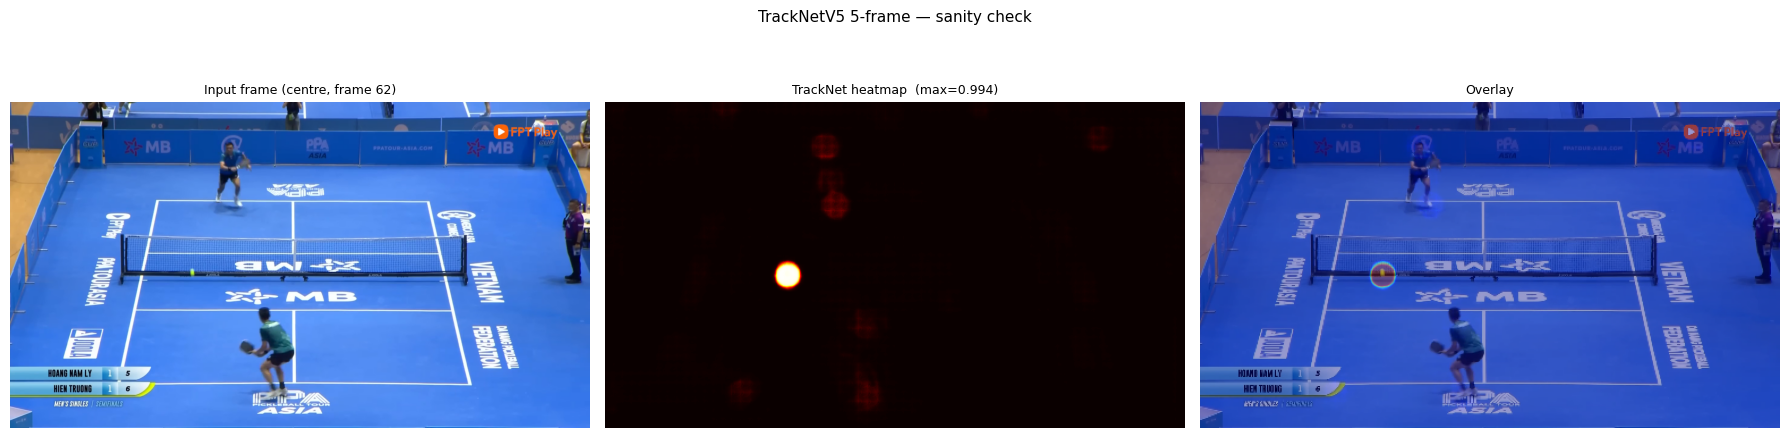

✅ Sanity check saved


In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt

assert os.path.exists(WEIGHTS),    f'Checkpoint not found: {WEIGHTS}'
assert os.path.exists(VIDEO_PATH), f'Video not found: {VIDEO_PATH}'

ckpt  = torch.load(WEIGHTS, map_location=DEVICE)
model = TrackNetV5_5frame().to(DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f' Model loaded')
print(f'   Trained epoch : {ckpt.get("epoch", "?")}')
print(f'   Best F1       : {ckpt.get("best_f1", "?"):.4f}')
print(f'   N_FRAMES      : {ckpt.get("n_frames", "?")}')
n_params = sum(p.numel() for p in model.parameters())
print(f'   Parameters    : {n_params/1e6:.2f}M')

cap   = cv2.VideoCapture(VIDEO_PATH)
VID_W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if MAX_FRAMES:
    TOTAL = min(TOTAL, MAX_FRAMES)
cap.release()

print(f'\n Video: {VID_W}×{VID_H} @ {FPS:.1f}fps  |  {TOTAL} frames  ({TOTAL/FPS:.1f}s)')

print('\nSanity check on frames 60-64...')
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
test_frames = []
for _ in range(5):
    ret, f = cap.read()
    if ret: test_frames.append(f)
cap.release()

def preprocess(frame_bgr):
    """BGR frame → normalised float32 tensor (3, IMG_H, IMG_W)"""
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (IMG_W, IMG_H))
    return torch.from_numpy(rgb.transpose(2, 0, 1)).float() / 255.0

tensors    = [preprocess(f) for f in test_frames]
quintuplet = torch.cat(tensors, dim=0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    hm = model(quintuplet)

hm_np = hm[0, 0].cpu().numpy()
print(f'   Input  : {tuple(quintuplet.shape)}')
print(f'   Output : {tuple(hm.shape)}')
print(f'   Heatmap min/max: {hm_np.min():.3f} / {hm_np.max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(test_frames[2], cv2.COLOR_BGR2RGB))
axes[0].set_title('Input frame (centre, frame 62)', fontsize=9); axes[0].axis('off')
axes[1].imshow(hm_np, cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'TrackNet heatmap  (max={hm_np.max():.3f})', fontsize=9)
axes[1].axis('off')
overlay = cv2.cvtColor(test_frames[2], cv2.COLOR_BGR2RGB).copy()
overlay = cv2.resize(overlay, (IMG_W, IMG_H))
hm_colour = cv2.applyColorMap((hm_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
hm_colour = cv2.cvtColor(hm_colour, cv2.COLOR_BGR2RGB)
axes[2].imshow(cv2.addWeighted(overlay, 0.6, hm_colour, 0.4, 0))
axes[2].set_title('Overlay', fontsize=9); axes[2].axis('off')
plt.suptitle('TrackNetV5 5-frame — sanity check', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()
print(f' Sanity check saved')

In [ ]:
def extract_ball_center(heatmap_tensor, threshold=TN_THRESH):
    """
    Extract ball centre from a 1×H×W heatmap tensor.
    Returns (cx, cy) in MODEL coordinates (512×288), or None.
    """
    hm      = heatmap_tensor.squeeze().cpu().numpy()
    binary  = (hm >= threshold).astype(np.uint8)
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c    = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    if area < TN_BLOB_MIN or area > TN_BLOB_MAX:
        return None
    M = cv2.moments(c)
    if M['m00'] == 0:
        return None
    return M['m10'] / M['m00'], M['m01'] / M['m00']

def model_to_video(cx, cy):
    """Scale model coords (512×288) → video coords (VID_W×VID_H)."""
    return int(cx * VID_W / IMG_W), int(cy * VID_H / IMG_H)

def draw_trail(frame, trail):
    """Draw fading coloured dot trail."""
    n = len(trail)
    for i, pt in enumerate(trail):
        if pt is None:
            continue
        t       = (i + 1) / n
        radius  = max(3, int(9 * t))
        alpha   = 0.15 + 0.85 * t
        color   = (int(50 + 180*t), int(220*t), int(255*(1-t)))
        overlay = frame.copy()
        cv2.circle(overlay, pt, radius, color, -1, cv2.LINE_AA)
        cv2.addWeighted(overlay, alpha, frame, 1-alpha, 0, frame)

def draw_detection(frame, cx, cy, conf=None):
    """Draw ball centre dot + optional confidence label."""
    color = (0, 255, 80)
    cv2.circle(frame, (cx, cy), 8, color, -1, cv2.LINE_AA)
    cv2.circle(frame, (cx, cy), 8, (255, 255, 255), 1, cv2.LINE_AA)
    if conf is not None:
        label = f'TN {conf:.2f}'
        cv2.putText(frame, label, (cx + 10, cy - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)

def draw_hud(frame, frame_idx, total, fps_proc, det, miss):
    """Top-bar status overlay."""
    W_f = frame.shape[1]
    ov  = frame.copy()
    cv2.rectangle(ov, (0, 0), (W_f, 36), (0, 0, 0), -1)
    cv2.addWeighted(ov, 0.55, frame, 0.45, 0, frame)
    det_pct = det / max(frame_idx, 1) * 100
    txt = (f'TrackNetV5 5-frame  |  '
           f'Frame {frame_idx}/{total}  |  {fps_proc:.1f} fps  |  '
           f'Det={det} ({det_pct:.1f}%)  Miss={miss}')
    cv2.putText(frame, txt, (10, 24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 128), 2, cv2.LINE_AA)

print(' Inference helpers defined')

✅ Inference helpers defined


In [ ]:
import time

print(f'Buffering {TOTAL} frames into RAM...')
t0 = time.time()

cap       = cv2.VideoCapture(VIDEO_PATH)
all_frames = []
while len(all_frames) < TOTAL:
    ret, frame = cap.read()
    if not ret:
        break
    all_frames.append(frame)
cap.release()

N = len(all_frames)
elapsed = time.time() - t0
print(f' {N} frames buffered in {elapsed:.1f}s  '
      f'({N * VID_W * VID_H * 3 / 1e9:.2f} GB RAM)')

print('Pre-processing frames...')
t0 = time.time()
preprocessed = [preprocess(f) for f in all_frames]
print(f' Pre-processing done in {time.time()-t0:.1f}s')

Buffering 180 frames into RAM...
✅ 180 frames buffered in 1.4s  (1.12 GB RAM)
Pre-processing frames...
✅ Pre-processing done in 0.5s


In [ ]:
from collections import deque

print(f'Running TrackNetV5 5-frame inference on {N} frames...')
print(f'  Frames 0-{HALF-1} and {N-HALF}-{N-1} skipped (boundary, need {HALF} context frames each side)')
print()

tn_results  = [None] * N
tn_heatmaps = [None] * N
last_cx = last_cy = None

t0 = time.time()

with torch.no_grad():
    for i in range(N):
        if i < HALF or i >= N - HALF:
            continue

        quintuplet = torch.cat(
            [preprocessed[i + d] for d in range(-HALF, HALF + 1)],
            dim=0
        ).unsqueeze(0).to(DEVICE)           # 1×15×288×512

        heatmap = model(quintuplet)

        tn_heatmaps[i] = heatmap[0, 0].cpu().numpy()

        center_model = extract_ball_center(heatmap[0])

        if center_model is not None:
            cx_vid, cy_vid = model_to_video(*center_model)

            if last_cx is not None:
                dist = np.hypot(cx_vid - last_cx, cy_vid - last_cy)
                if dist > TN_MAX_TRAVEL:
                    center_model = None

        if center_model is not None:
            tn_results[i] = (cx_vid, cy_vid)
            last_cx, last_cy = cx_vid, cy_vid
        else:
            last_cx = last_cy = None

        if (i + 1) % 100 == 0 or i == N - 1:
            det  = sum(1 for r in tn_results if r is not None)
            fps  = (i + 1) / (time.time() - t0)
            eta  = (N - i - 1) / fps
            print(f'  [{i+1:>4}/{N}]  {fps:.1f} fps  '
                  f'det={det} ({det/(i+1)*100:.1f}%)  '
                  f'ETA {eta:.0f}s')

elapsed = time.time() - t0
det_count  = sum(1 for r in tn_results if r is not None)
miss_count = N - det_count - 2 * HALF

print(f'\n{"="*55}')
print(f' Inference done in {elapsed:.1f}s  ({N/elapsed:.1f} fps avg)')
print(f'   Detected : {det_count} ({det_count/N*100:.1f}%)')
print(f'   Missed   : {miss_count}')
print(f'   Skipped  : {2*HALF} (boundary)')
print('='*55)

Running TrackNetV5 5-frame inference on 180 frames...
  Frames 0-1 and 178-179 skipped (boundary, need 2 context frames each side)

  [ 100/180]  20.9 fps  det=88 (88.0%)  ETA 4s

✅ Inference done in 8.5s  (21.2 fps avg)
   Detected : 162 (90.0%)
   Missed   : 14
   Skipped  : 4 (boundary)


In [ ]:
print(f'Rendering output video...')
print(f'   Output → {OUTPUT_VIDEO}')

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*'mp4v'),
    FPS, (VID_W, VID_H)
)

trail     = deque([None] * TRAIL_LEN, maxlen=TRAIL_LEN)
det_count = miss_count = 0
t0        = time.time()

for i, frame in enumerate(all_frames):
    vis_frame = frame.copy()
    result    = tn_results[i]

    if result is not None:
        trail.append(result)
        det_count += 1
    else:
        trail.append(None)
        if i >= HALF and i < N - HALF:
            miss_count += 1

    draw_trail(vis_frame, trail)

    if result is not None:
        draw_detection(vis_frame, result[0], result[1])

    fps_proc = (i + 1) / max(time.time() - t0, 1e-6)
    draw_hud(vis_frame, i + 1, N, fps_proc, det_count, miss_count)

    writer.write(vis_frame)

writer.release()
print(f' Video saved → {OUTPUT_VIDEO}')

Rendering output video...
   Output → /content/drive/MyDrive/In_Out_Pickleball/tracknet_test_results/fourth_output.mp4
✅ Video saved → /content/drive/MyDrive/In_Out_Pickleball/tracknet_test_results/fourth_output.mp4


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frame_indices = list(range(N))
detected      = [tn_results[i] is not None for i in range(N)]
cx_arr        = [tn_results[i][0] if tn_results[i] else np.nan for i in range(N)]
cy_arr        = [tn_results[i][1] if tn_results[i] else np.nan for i in range(N)]

hm_peaks = []
hm_frames = []
for i in range(N):
    if tn_heatmaps[i] is not None:
        hm_peaks.append(float(tn_heatmaps[i].max()))
        hm_frames.append(i)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle(f'TrackNetV5 5-frame — {os.path.basename(VIDEO_PATH)}',
             fontsize=12)

ax = axes[0]
ax.fill_between(frame_indices, [1 if d else 0 for d in detected],
                step='mid', alpha=0.6, color='tab:green', label='Detected')
ax.fill_between(frame_indices,
                [1 if (not d and i>=HALF and i<N-HALF) else 0
                 for i, d in enumerate(detected)],
                step='mid', alpha=0.3, color='tab:red', label='Missed')
ax.axvspan(0, HALF, alpha=0.15, color='grey', label='Boundary skip')
ax.axvspan(N-HALF, N, alpha=0.15, color='grey')
ax.set_title(f'Detection rate: {sum(detected)/N*100:.1f}%', fontsize=9)
ax.set_ylabel('Detected'); ax.set_yticks([0, 1])
ax.set_yticklabels(['No', 'Yes']); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

ax = axes[1]
det_idx = [i for i in range(N) if tn_results[i] is not None]
det_cy  = [tn_results[i][1] for i in det_idx]
if det_idx:
    sc = ax.scatter(det_idx, det_cy, s=5,
                    c=[hm_peaks[hm_frames.index(i)] if i in hm_frames else 0.5
                       for i in det_idx],
                    cmap='RdYlGn', vmin=0, vmax=1, alpha=0.8)
    plt.colorbar(sc, ax=ax, pad=0.01, label='heatmap peak')
ax.invert_yaxis()
ax.set_title('Ball vertical position (colour = heatmap confidence)', fontsize=9)
ax.set_ylabel('Ball Y (px, top=0)'); ax.grid(True, alpha=0.2)

ax = axes[2]
if hm_peaks:
    ax.hist(hm_peaks, bins=40, color='tab:blue', alpha=0.75, edgecolor='white')
    ax.axvline(TN_THRESH, color='red', linestyle='--', lw=1.5,
               label=f'threshold={TN_THRESH}')
    ax.axvline(np.mean(hm_peaks), color='green', linestyle='--', lw=1.5,
               label=f'mean={np.mean(hm_peaks):.3f}')
ax.set_xlabel('Heatmap peak value'); ax.set_ylabel('Count')
ax.set_title('Heatmap confidence distribution', fontsize=9)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plot_path = f'{OUTPUT_DIR}/tracknet_analysis.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Analysis plot saved → {plot_path}')

print(f'\n{"="*55}')
print(f'DETECTION SUMMARY')
print(f'{"="*55}')
print(f'  Total frames   : {N}')
print(f'  Boundary skip  : {2*HALF} ({HALF} each side)')
print(f'  Detections     : {sum(detected)} ({sum(detected)/N*100:.1f}%)')
print(f'  Missed         : {N - sum(detected) - 2*HALF}')
if hm_peaks:
    print(f'  Heatmap mean   : {np.mean(hm_peaks):.3f}')
    print(f'  Heatmap min/max: {np.min(hm_peaks):.3f} / {np.max(hm_peaks):.3f}')
    above = sum(p > 0.7 for p in hm_peaks)
    print(f'  Conf > 0.7     : {above} ({above/len(hm_peaks)*100:.1f}%)')
print('='*55)

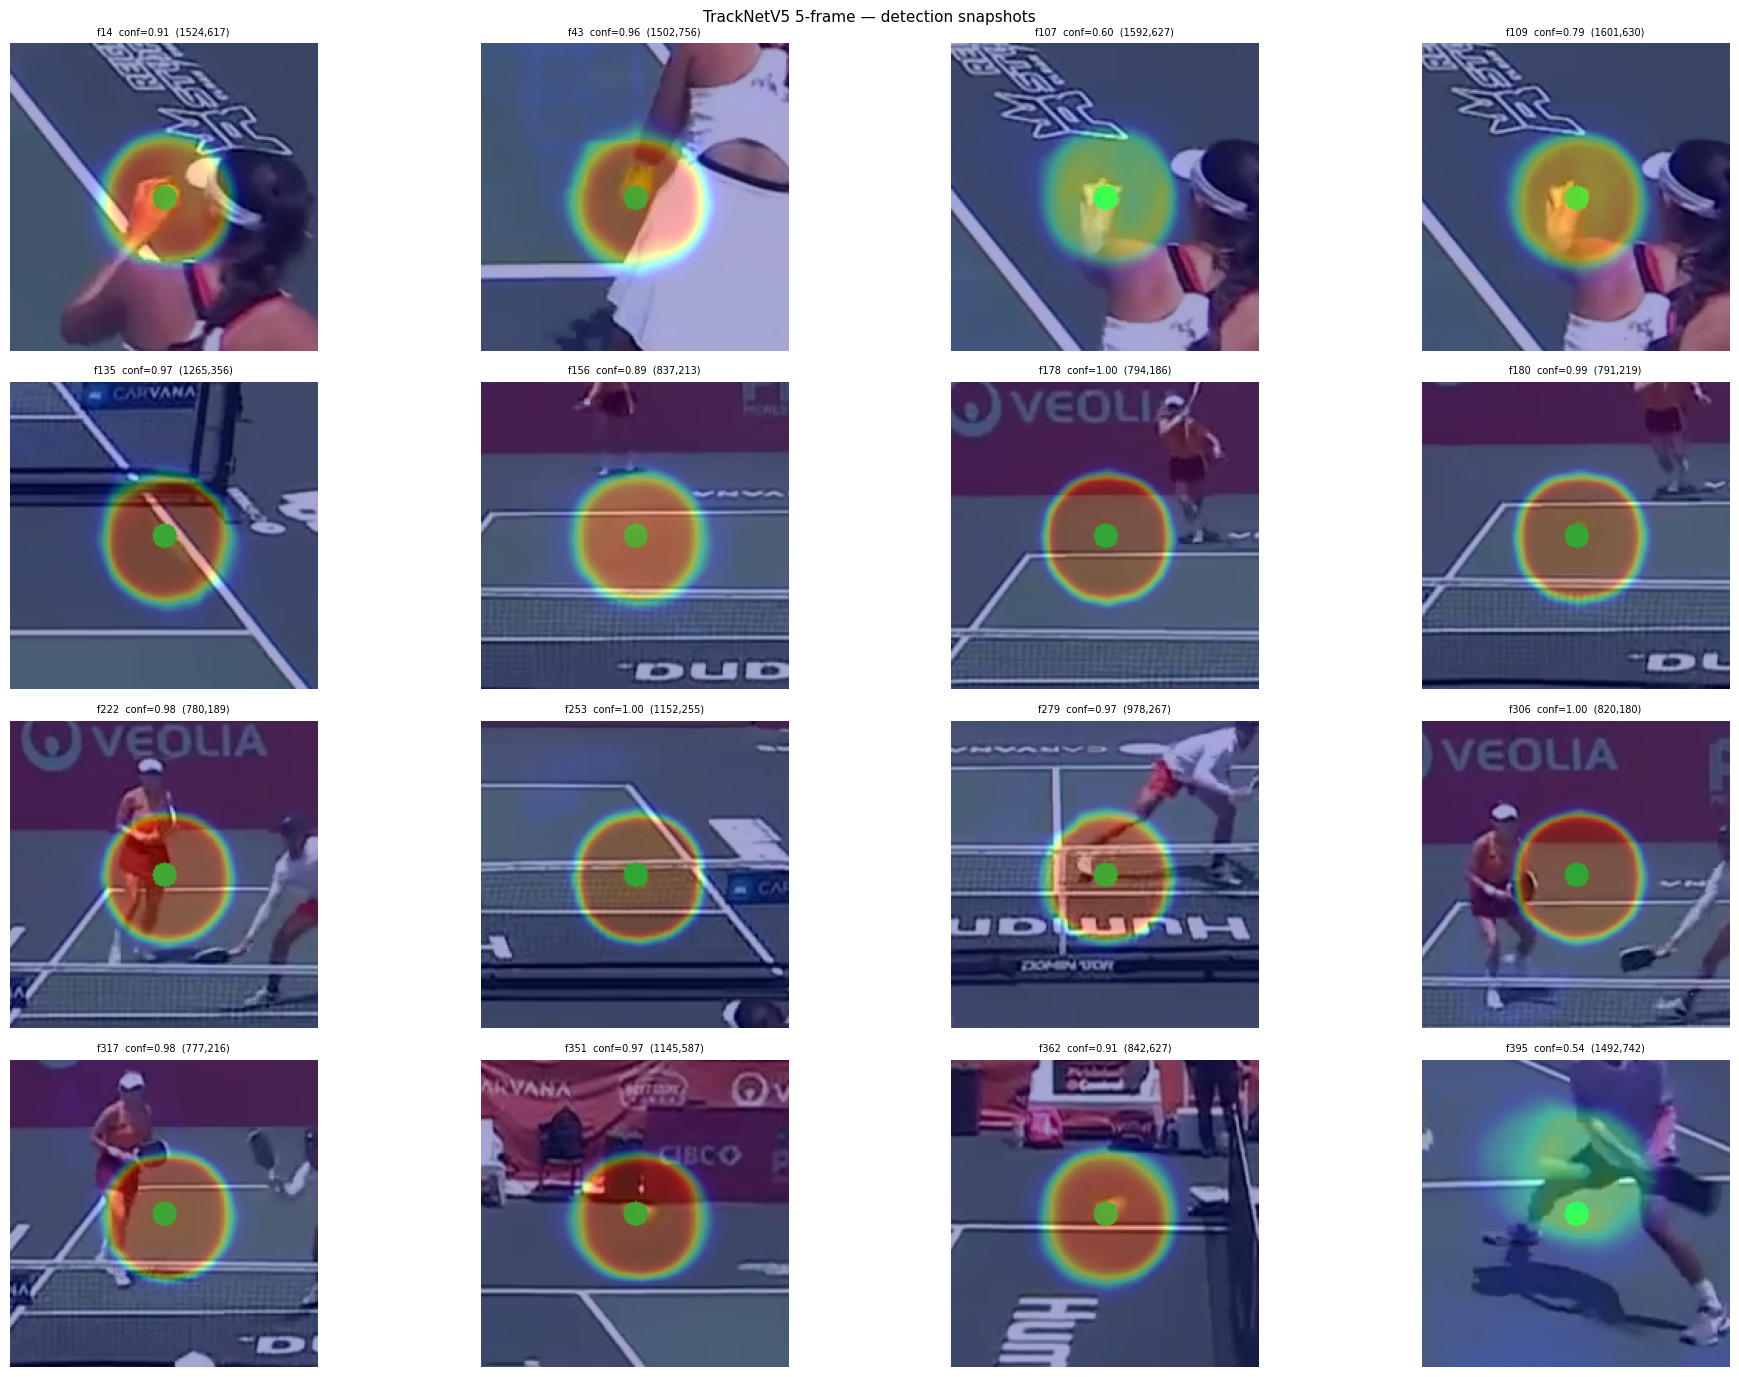

✅ Snapshots saved → /content/drive/MyDrive/In_Out_Pickleball/tracknet_test_results/tracknet_snapshots.png


In [ ]:
import random

N_SNAPS = 16
COLS    = 4

det_frames = [i for i in range(N) if tn_results[i] is not None]
if not det_frames:
    print('No detections — check threshold or weights')
else:
    samples = sorted(random.sample(det_frames, min(N_SNAPS, len(det_frames))))
    rows    = (len(samples) + COLS - 1) // COLS

    fig, axes = plt.subplots(rows, COLS, figsize=(COLS*5, rows*3.5))
    axes      = axes.flatten()

    for idx, fidx in enumerate(samples):
        ax = axes[idx]
        cx, cy = tn_results[fidx]
        pad = 100
        x1  = max(0, cx - pad); y1 = max(0, cy - pad)
        x2  = min(VID_W, cx + pad); y2 = min(VID_H, cy + pad)
        crop = cv2.cvtColor(all_frames[fidx][y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

        dot_crop = crop.copy()
        cv2.circle(dot_crop, (cx-x1, cy-y1), 8, (0, 255, 80), -1)

        if tn_heatmaps[fidx] is not None:
            hm_full = cv2.resize(tn_heatmaps[fidx],
                                  (VID_W, VID_H),
                                  interpolation=cv2.INTER_LINEAR)
            hm_crop = hm_full[y1:y2, x1:x2]
            hm_col  = cv2.applyColorMap(
                (hm_crop * 255).astype(np.uint8), cv2.COLORMAP_JET)
            hm_col  = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
            dot_crop = cv2.addWeighted(dot_crop, 0.65, hm_col, 0.35, 0)

        ax.imshow(dot_crop)
        peak = tn_heatmaps[fidx].max() if tn_heatmaps[fidx] is not None else 0
        ax.set_title(f'f{fidx}  conf={peak:.2f}  ({cx},{cy})', fontsize=7)
        ax.axis('off')

    for j in range(len(samples), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'TrackNetV5 5-frame — detection snapshots', fontsize=11)
    plt.tight_layout()
    snap_path = f'{OUTPUT_DIR}/tracknet_snapshots.png'
    plt.savefig(snap_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Snapshots saved → {snap_path}')

In [ ]:
TUNE_START = 0
TUNE_N     = min(200, N)

print(f'Tuning threshold on frames {TUNE_START}–{TUNE_START+TUNE_N}...')

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
results_by_thr = {}

for thr in thresholds:
    dets = 0
    lx = ly = None
    for i in range(TUNE_START + HALF, TUNE_START + TUNE_N - HALF):
        hm = tn_heatmaps[i]
        if hm is None:
            continue
        binary = (hm >= thr).astype(np.uint8)
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
        center = None
        if cnts:
            c    = max(cnts, key=cv2.contourArea)
            area = cv2.contourArea(c)
            if TN_BLOB_MIN <= area <= TN_BLOB_MAX:
                M = cv2.moments(c)
                if M['m00'] > 0:
                    cx_m = M['m10'] / M['m00']
                    cy_m = M['m01'] / M['m00']
                    cx_v, cy_v = model_to_video(cx_m, cy_m)
                    if lx is not None:
                        if np.hypot(cx_v-lx, cy_v-ly) <= TN_MAX_TRAVEL:
                            center = (cx_v, cy_v)
                    else:
                        center = (cx_v, cy_v)
        if center:
            dets += 1; lx, ly = center
        else:
            lx = ly = None

    n_eval = TUNE_N - 2 * HALF
    results_by_thr[thr] = dets
    print(f'  thr={thr:.2f}  →  {dets}/{n_eval} ({dets/n_eval*100:.1f}%) detected')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(t) for t in thresholds],
       [results_by_thr[t] for t in thresholds],
       color='tab:blue', alpha=0.8, edgecolor='white')
ax.axhline((TUNE_N - 2*HALF) * 0.7, color='green', linestyle='--',
           label='70% target')
ax.set_xlabel('Threshold'); ax.set_ylabel('Frames detected')
ax.set_title(f'Detection count vs threshold  ({TUNE_N} frames)', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/threshold_tuning.png', dpi=120)
plt.show()

best_thr = max(thresholds, key=lambda t: results_by_thr[t])
print(f'\n→ Best threshold in this clip: {best_thr}')
print(f'  Update TN_THRESH in Cell 1 and re-run cells 6-7 if needed')